<a href="https://colab.research.google.com/github/suzetteabascal10-byte/Simulacion-I/blob/main/Linea_de_espera_un_servidor_Abascal_Rojas_Suzette_Sarahi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Linea de espera de un servidor

In [10]:
import numpy as np
import matplotlib.pyplot as plt

lambda_ = 4
mu = 6
T = 1000
np.random.seed(42)

def gen_exp(rate):
    return -np.log(np.random.random()) / rate

t = 0.0
t_A = gen_exp(lambda_)
t_D = float('inf')
n = 0
N_A = 0

cola = []
llegadas = []
inicios = []
salidas = []

area_sistema = 0.0
area_cola = 0.0
t_prev = 0.0

def actualizar_areas(t_actual):
    global area_sistema, area_cola, t_prev, n
    dt = t_actual - t_prev
    if dt > 0:
        area_sistema += n * dt
        area_cola += max(0, n - 1) * dt
    t_prev = t_actual

while t < T:
    if t_A <= t_D and t_A <= T:
        actualizar_areas(t_A)
        t = t_A
        N_A += 1
        n += 1
        llegadas.append(t)

        t_A = t + gen_exp(lambda_)

        if n == 1:
            Y = gen_exp(mu)
            t_D = t + Y
            inicios.append(t)
        else:
            cola.append(t)

    else:
        actualizar_areas(t_D)
        t = t_D
        n -= 1
        salidas.append(t)

        if n > 0:
            siguiente_llegada = cola.pop(0)
            Y = gen_exp(mu)
            t_D = t + Y
            inicios.append(t)
        else:
            t_D = float('inf')

actualizar_areas(T)

en esta parte del codigo desarrolamos las variables delimitadas asi como las llistas vacias para ir almacenando informacion obtenida de los clientes, como los tiempos de llegada, a cantidad de clientes esperando, y su salida.
Para generar todo ello se generan numeros aleatorios para tanto el tiempo como el numero de clientes que van llegando, así como indica el seudocodigo.

Comparacion de solucion analitica y simulada
lambda = 4, mu = 6, rho = 0.6667
Tiempo simulado: 1000.00
Clientes atendidos: 3898


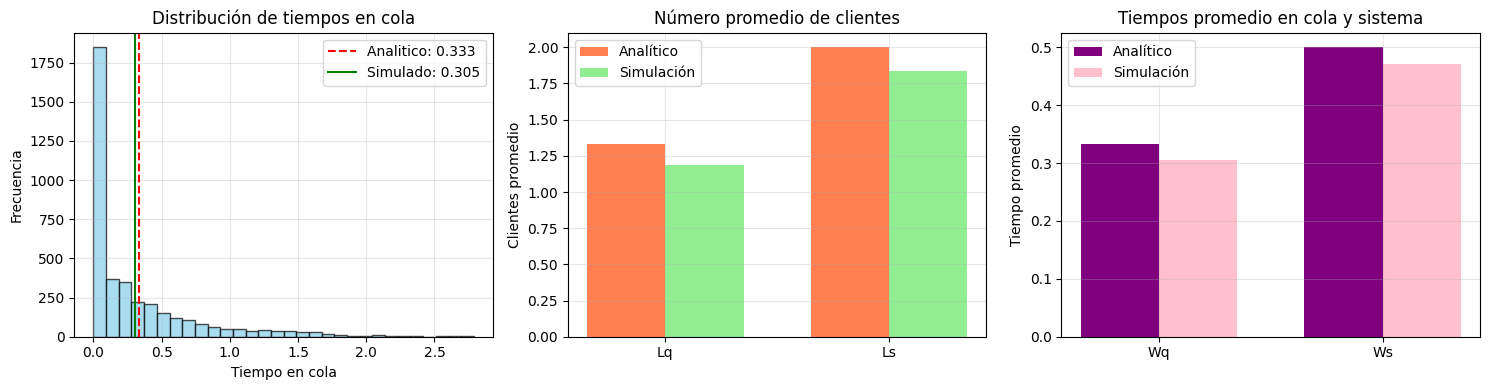

In [13]:
tiempo_total = T
Lq_sim = area_cola / tiempo_total
Ls_sim = area_sistema / tiempo_total

tiempos_cola = []
tiempos_sistema = []
for i in range(len(llegadas)):
    if i < len(inicios) and i < len(salidas):
        wq = inicios[i] - llegadas[i]
        ws = salidas[i] - llegadas[i]
        tiempos_cola.append(wq)
        tiempos_sistema.append(ws)

Wq_sim = np.mean(tiempos_cola) if tiempos_cola else 0
Ws_sim = np.mean(tiempos_sistema) if tiempos_sistema else 0

rho = lambda_ / mu
P0_sim = 1 - rho

rho_analitico = lambda_ / mu
P0_analitico = 1 - rho_analitico
Lq_analitico = (lambda_**2) / (mu * (mu - lambda_))
Ls_analitico = Lq_analitico + lambda_ / mu
Wq_analitico = Lq_analitico / lambda_
Ws_analitico = Wq_analitico + 1 / mu

print("=" * 60)
print("Comparacion de solucion analitica y simulada")
print("lambda = {}, mu = {}, rho = {:.4f}".format(lambda_, mu, rho_analitico))
print("Tiempo simulado: {:.2f}".format(tiempo_total))
print("Clientes atendidos: {}".format(len(salidas)))
print("=" * 60)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].hist(tiempos_cola, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axs[0].axvline(Wq_analitico, color='red', linestyle='--', label="Analitico: {:.3f}".format(Wq_analitico))
axs[0].axvline(Wq_sim, color='green', linestyle='-', label="Simulado: {:.3f}".format(Wq_sim))
axs[0].set_xlabel('Tiempo en cola')
axs[0].set_ylabel('Frecuencia')
axs[0].set_title('Distribución de tiempos en cola')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

metricas = ['Lq', 'Ls']
analitico = [Lq_analitico, Ls_analitico]
simulacion = [Lq_sim, Ls_sim]
x = np.arange(len(metricas))
width = 0.35
axs[1].bar(x - width/2, analitico, width, label='Analítico', color='coral')
axs[1].bar(x + width/2, simulacion, width, label='Simulación', color='lightgreen')
axs[1].set_ylabel('Clientes promedio')
axs[1].set_title('Número promedio de clientes')
axs[1].set_xticks(x)
axs[1].set_xticklabels(metricas)
axs[1].legend()
axs[1].grid(True, alpha=0.3)

metricas2 = ['Wq', 'Ws']
analitico2 = [Wq_analitico, Ws_analitico]
simulacion2 = [Wq_sim, Ws_sim]
axs[2].bar(x - width/2, analitico2, width, label='Analítico', color='purple')
axs[2].bar(x + width/2, simulacion2, width, label='Simulación', color='pink')
axs[2].set_ylabel('Tiempo promedio')
axs[2].set_title('Tiempos promedio en cola y sistema')
axs[2].set_xticks(x)
axs[2].set_xticklabels(metricas2)
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Su estructura se basa en el de llegadas con la respectiva salida. También incluye una comparación directa entre las métricas simuladas y los resultados analíticos para ver que la simulacion es la correcta para este problema; para despues generar gráficas para facilitar la interpretación de los datos obtenidos.